read more about the dataset here - https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland/data
## EXPLORATORY DATA ANALYSIS (heart disease dataset.)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.ensemble import RandomForestClassifier

let me start the eda with heart.csv which probably consists data for heart related deseases . first , importing the csv as dataframe.

In [3]:
df_heart = pd.read_csv('/home/spandan/Documents/ML/disease-predictor/data/heart.csv')
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


alright so the heart.csv consists of columns these columns :

In [4]:
df_heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

DATABASE INFORMATION GIVEN :-

1. Age: Patients Age in years (Numeric)
2. Sex: Gender (Male : 1; Female : 0) (Nominal)
3. cp: Type of chest pain experienced by patient. This term categorized into 4 category.
    0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
4. trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)
5. chol: Serum cholesterol in mg/dl (Numeric)
6. fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false        (Nominal)
7. restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
   0 : Normal 
   1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) 
   2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
8. thalach: Maximum heart rate achieved (Numeric)
9. exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
10. oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
11. slope: ST segment measured in terms of slope during peak exercise
    0: up sloping; 1: flat; 2: down sloping(Nominal)
12. ca: The number of major vessels (0–3)(nominal)
13. thal: A blood disorder called thalassemia
    0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
14. target: It is the target variable which we have to predict 1 means patient is suffering from heart   disease and 0 means patient is normal.

In [5]:
df_heart.shape

(303, 14)

so there are 303 entries.

In [6]:
df_heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [8]:
df_heart['target'].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

this means 164 ppl in this dataset are not suffering from heart disease where as 139 are.
and yes , the dataset is balanced ! distribution is 54% and 45 %
lets draw a corelation heatmap so we can understand power independent columns.

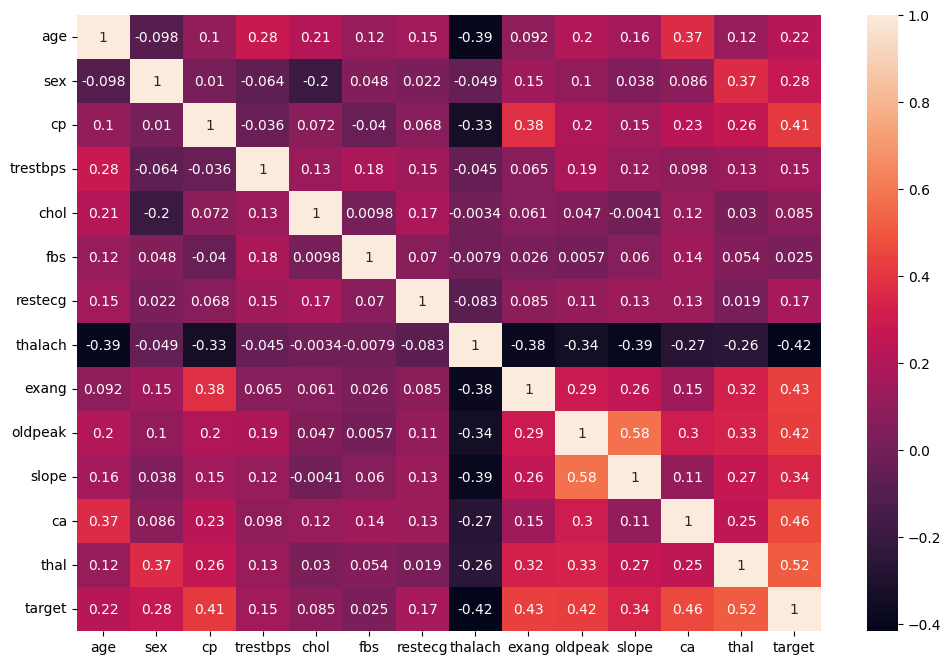

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df_heart.corr() , annot=True)
plt.show()

the correlation heatmap states strong positive relations with target at
1. thal = 0.52
2. ca = 0.46
3. exang = 0.43
4. oldpeak = 0.42 
5. cp = 0.41
all these would probably result in heart disease.
now lets look at the negetive relation(s).
1. thalach = -0.42
meaning having these would probably result in no heart disease

other notes --
slope x oldpeak is strong 0.58 , could be considered for multicoliniarity or logistic regression.


alr then lets try different models onto the data. as discussed our y would be the df_heart['target'] column , and rest are independent variables.

In [10]:
x = df_heart.drop('target' , axis = 1) #independent variables
y = df_heart['target'] #dependent variable

lets split the dataset for training and testing with 80/20 proportion.

In [11]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

the data we have rn , is having a varity of scales . so lets do feature scaling and perform standerdization on the data to bring datapoints closer and in same scale.

In [12]:
scaler = StandardScaler()
''' 
back of the hood , the scaler probably uses the bell shaped curve normalization where we calculate z
by formula (x - mean)/std_dev
'''

' \nback of the hood , the scaler probably uses the bell shaped curve normalization where we calculate z\nby formula (x - mean)/std_dev\n'

In [13]:
x_train = scaler.fit_transform(x_train) # meaning scale x_train and store it in same var x_train 

In [14]:
#doing same for x_test
x_test = scaler.fit_transform(x_test)

## Logistic Regression
starting with model testings , we start with logistic regression. as we know logistic
regression is used for classification , especially binary classification. like 0 or 1

why not linear regression ? because we dont want a continues output (like 1.7 , 0.3) we want 1 or 0 !

In [15]:
model = LogisticRegression()

In [16]:
'''
starting with the model fitting or training the logistic regression model with our standardized data
'''
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

lets understand the predictions

In [17]:
y_pred = model.predict(x_test)

plotting a confusion matrix to understand the predictions

In [18]:
cf = confusion_matrix(y_test,y_pred)

print(cf)

[[26  3]
 [ 5 27]]


meaning , we have
TP = 26
FN = 3
FP = 5
TN = 27

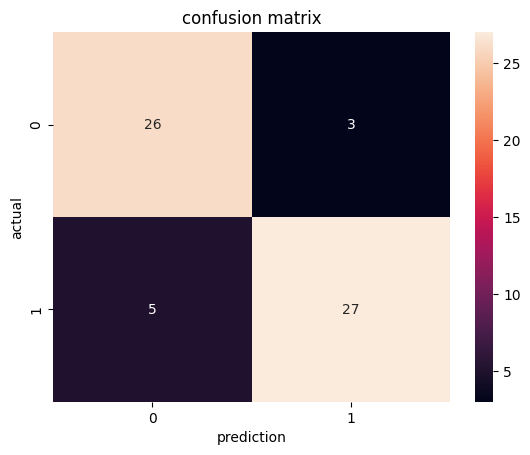

In [19]:
sns.heatmap(cf , annot=True)
plt.title('confusion matrix')
plt.xlabel('prediction')
plt.ylabel('actual')
plt.show()

In [20]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [21]:
coefficients = pd.DataFrame(
    model.coef_[0],
    index = x.columns,
    columns = ['coefficient']
)
#making a dataframe to understand the coefficient weightage for prediction.

coefficients.sort_values(by='coefficient' , ascending=False)

,coefficient
ca,1.145020
sex,0.709469
cp,0.506950
thal,0.500975
slope,0.436854
exang,0.434295
chol,0.428796
oldpeak,0.341609
trestbps,0.325428
restecg,0.142721


so what exactly did i do just now ? the dataframe which i made in this code block consists of the coefficient values of what exactly the model learned from. soo the more bigger the positive value is , the bigger influence it does on the prediction. 

simplified explaination :

1. the more positive a coefficient -> increases probability of heart disease.
2. the more negetive a coefficient -> decreases probability of heart disease

- strong positive influencing fields -> ca , sex , thal , exang
- strong negetive influencing fields -> thalach , fbs

## Random Forest
considering other model option for the project , a random forest is perfect choice. why ? 
if we use a decision tree , a single decesion tree then it can overfit badly . like it will probably
mug or memorize the training data and perform poorly on test data.

random forest will create many trees instead of one and then after a voting type system we will have our prediction

In [22]:
randomForestModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

here we are taking n_estimators (or number of *decision trees*) as 100 with a randomness 42.

In [23]:
randomForestModel.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
randomForest_prediction = randomForestModel.predict(x_test) #making predictions
print(classification_report(y_test , randomForest_prediction))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



well the randomforest did perform well. talking about accuracy it is similar to that of logistic regression. but :
- precision is 93 % for predicting heart disease correctly.
this is quite impressive.

lets check the importance 

In [25]:
importance = pd.DataFrame({
    "Features"  : x.columns,
    "Importance" : randomForestModel.feature_importances_
})
importance = importance.sort_values(by =  "Importance" , ascending=False)

importance

,Features,Importance
2,cp,0.127280
7,thalach,0.116200
9,oldpeak,0.113342
11,ca,0.112550
0,age,0.105167
12,thal,0.095484
4,chol,0.079107
3,trestbps,0.074830
10,slope,0.055162
8,exang,0.051821


intresting. lets plot a bargraph to understand this cleanely

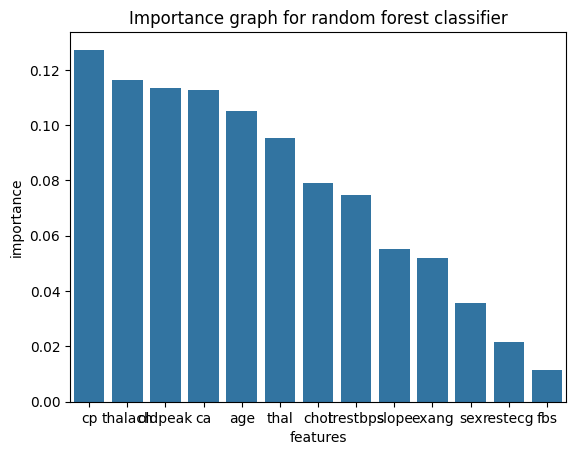

In [26]:
plt.Figure(figsize=(12,30))
sns.barplot(
    x = importance['Features'],
    y = importance['Importance'],
    data = importance
)
plt.title("Importance graph for random forest classifier")
plt.xlabel("features")
plt.ylabel("importance")
plt.show()

so the randomforest relied the most on cp , thalach  , oldpeak , ca

considering the more flixible outcomes from random forest with
- similar accuracy
- good feature importance
- better real world robustness
we will finalize **random forest model** for our heart disease predictor

--
while taking user input , many features are very much irrelevent to take from user , so lets just reduce some of the features and try the accuracy of model again.

-- for graph genration research

In [28]:
mean_chol_0 = df_heart[df_heart['target'] == 0]['chol'].mean()

In [29]:
mean_chol_1 = df_heart[df_heart['target'] == 1]['chol'].mean()

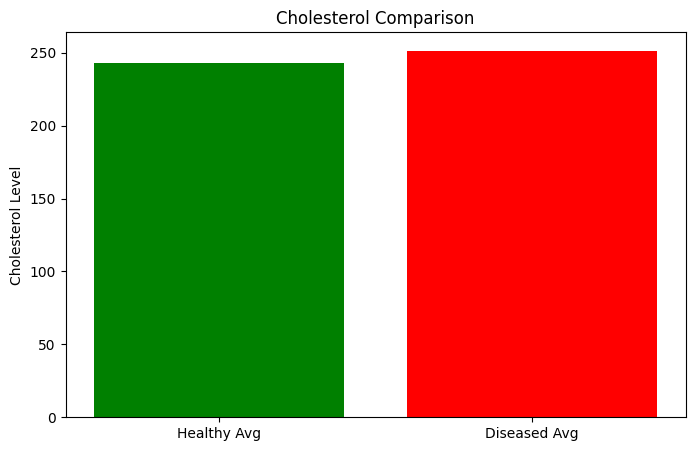

In [ ]:
labels = ['Healthy Avg', 'Diseased Avg']

values = [
    mean_chol_0,
    mean_chol_1,
]

colors = ['green', 'red']

plt.figure(figsize=(8, 5))

plt.bar(labels, values, color=colors)

plt.title('Cholesterol Comparison')

plt.ylabel('Cholesterol Level')

plt.show()

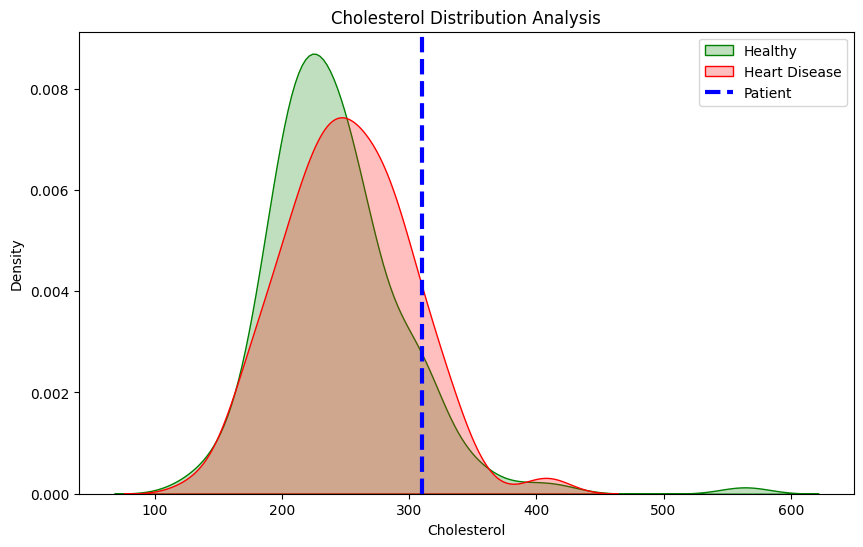

In [ ]:

#CHOLESTROL GRAPH FOR HEART 

patient_chol = 310

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_heart[df_heart['target'] == 0],
    x='chol',
    fill=True,
    color='green',
    label='Healthy'
)

sns.kdeplot(
    data=df_heart[df_heart['target'] == 1],
    x='chol',
    fill=True,
    color='red',
    label='Heart Disease'
)

plt.axvline(
    patient_chol,
    color='blue',
    linestyle='--',
    linewidth=3,
    label='Patient'
)

plt.title('Cholesterol Distribution Analysis')

plt.xlabel('Cholesterol')

plt.ylabel('Density')

plt.legend()

plt.show()





/tmp/ipykernel_21126/4135162187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


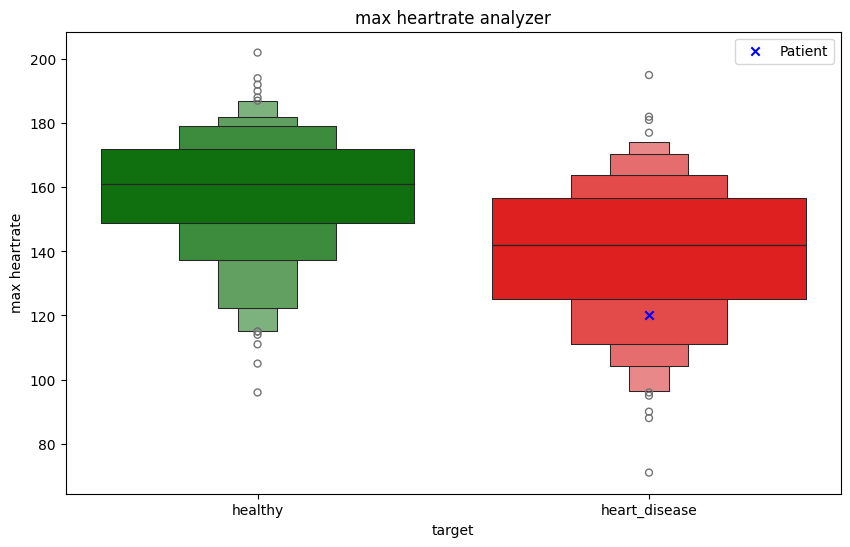

In [ ]:
#thalach graph for ehart

plt.figure(figsize = (10,6))
patient_thalach = 120
patient_categoru_x = 1
sns.boxenplot(
    data = df_heart,
    x = 'target',
    y = 'thalach',

    palette=['green' , 'red']
)

plt.scatter(patient_categoru_x ,
            patient_thalach,
            color= 'blue',
            marker='x',
            label = 'Patient')

plt.xticks([0,1] , ['healthy' , 'heart_disease'])
plt.title('max heartrate analyzer')
plt.ylabel('max heartrate')
plt.legend()
plt.show()

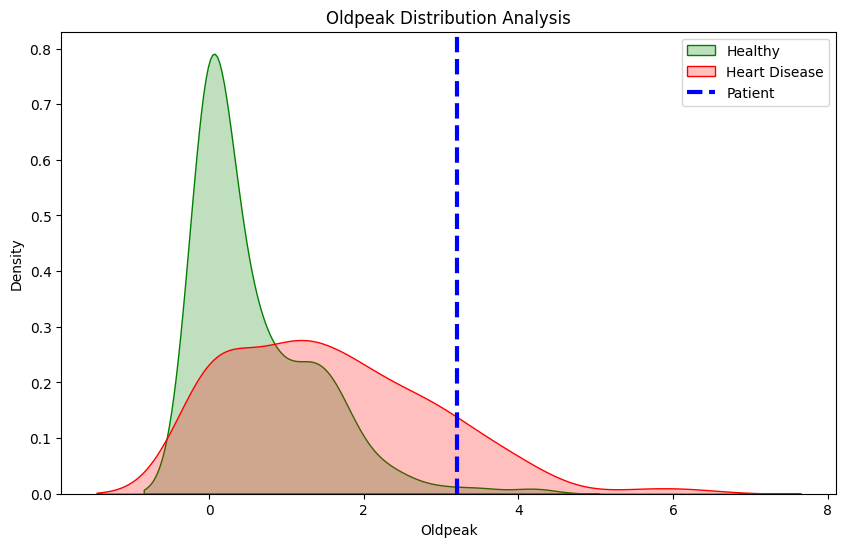

In [40]:
plt.figure(figsize=(10,6))

patient_oldpeak = 3.2

sns.kdeplot(
    data=df_heart[df_heart['target'] == 0],
    x='oldpeak',
    fill=True,
    color='green',
    label='Healthy'
)

sns.kdeplot(
    data=df_heart[df_heart['target'] == 1],
    x='oldpeak',
    fill=True,
    color='red',
    label='Heart Disease'
)

plt.axvline(
    patient_oldpeak,
    color='blue',
    linestyle='--',
    linewidth=3,
    label='Patient'
)

plt.title('Oldpeak Distribution Analysis')

plt.xlabel('Oldpeak')

plt.ylabel('Density')

plt.legend()

plt.show()